# Validation 3: fixed-n Bayes-factor plots

Plot the fixed-500 synthetic model-comparison results saved by `section_3/script/operation_3_bf_500.py`.

The simulation and SMC inference are no longer run in this notebook. Generate or refresh the results from the terminal, for example:

```bash
python3 section_3/script/operation_3_bf_500.py --n_cells 500
```

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import scienceplots
    plt.style.use("science")
except ModuleNotFoundError:
    plt.style.use("default")

PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "section_3" / "script" / "operation_3_bf_500.py").exists()
)

N_CELLS = 500
RESULT_ROOT = PROJECT_ROOT / "section_3" / "results" / "part_3_bf_500"
FIGURE_ROOT = PROJECT_ROOT / "section_3" / "figures" / "part_3_bf_500"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = RESULT_ROOT / f"logml_summary_n{N_CELLS}.csv"
SCENARIOS_PATH = RESULT_ROOT / "scenarios.csv"

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing {SUMMARY_PATH}. Run section_3/script/operation_3_bf_500.py first."
    )

summary_df = pd.read_csv(SUMMARY_PATH)
scenarios_df = pd.read_csv(SCENARIOS_PATH) if SCENARIOS_PATH.exists() else pd.DataFrame()

pd.set_option("display.max_columns", 120)
summary_df.head()

,scenario,scenario_label,replicate,simulation_seed,gt_mean_lambda,gt_sigma_lambda,gt_p0,gt_sigma_eta,gt_beta_x,gt_beta_y,true_model,best_model,n_cells,model,logml,log_bf_model_vs_true,log10_bf_model_vs_true,log_bf_model_vs_best,log10_bf_model_vs_best
0,No1,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",1,10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,heterogeneous_history_dependent,500,homogeneous_history_independent,-2539.755250,-80.344178,-34.893033,-80.344178,-34.893033
1,No1,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",1,10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,heterogeneous_history_dependent,500,homogeneous_history_dependent,-2462.466122,-3.055050,-1.326791,-3.055050,-1.326791
2,No1,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",1,10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,heterogeneous_history_dependent,500,heterogeneous_history_independent,-2542.570526,-83.159454,-36.115692,-83.159454,-36.115692
3,No1,"No1: sigma_eta=0.75, beta=(0.8,-0.8)",1,10310,4.0,2.0,0.25,0.75,0.8,-0.8,heterogeneous_history_dependent,heterogeneous_history_dependent,500,heterogeneous_history_dependent,-2459.411072,0.000000,0.000000,0.000000,0.000000
4,No2,"No2: sigma_eta=0.75, beta=(0,0)",1,10311,4.0,2.0,0.25,0.75,0.0,0.0,heterogeneous_history_independent,heterogeneous_history_independent,500,homogeneous_history_independent,-2350.713022,-14.101795,-6.124332,-14.101795,-6.124332


In [2]:
MODEL_ORDER = [
    "homogeneous_history_independent",
    "homogeneous_history_dependent",
    "heterogeneous_history_independent",
    "heterogeneous_history_dependent",
]
MODEL_DISPLAY = {
    "homogeneous_history_independent": "Hom / HI",
    "homogeneous_history_dependent": "Hom / HD",
    "heterogeneous_history_independent": "Het / HI",
    "heterogeneous_history_dependent": "Het / HD",
}
MODEL_COLORS = {
    "homogeneous_history_independent": "#809bce",
    "homogeneous_history_dependent": "#95b8d1",
    "heterogeneous_history_independent": "#b8e0d4",
    "heterogeneous_history_dependent": "#d6eadf",
}
SCENARIO_ROMAN = {
    "No1": "i",
    "No2": "ii",
    "No3": "iii",
    "No4": "iv",
}


def scenario_order(data: pd.DataFrame) -> list[str]:
    preferred = ["No1", "No2", "No3", "No4"]
    present = set(data["scenario"].astype(str))
    ordered = [scenario for scenario in preferred if scenario in present]
    ordered.extend(sorted(present.difference(ordered)))
    return ordered


def scenario_title(row: pd.Series) -> str:
    scenario_label = SCENARIO_ROMAN.get(str(row["scenario"]), str(row["scenario"]))
    return (
        f"({scenario_label}) "
        f"sigma_eta={float(row['gt_sigma_eta']):g}, "
        f"beta_x={float(row['gt_beta_x']):g}, "
        f"beta_y={float(row['gt_beta_y']):g}"
    )


def fixed_n_comparison_table(summary: pd.DataFrame) -> pd.DataFrame:
    table = summary.copy()
    table["model_label"] = table["model"].map(MODEL_DISPLAY).fillna(table["model"])
    out = table.pivot_table(
        index=["scenario", "replicate", "true_model", "best_model"],
        columns="model_label",
        values="log10_bf_model_vs_true",
        aggfunc="first",
    )
    display_order = [label for label in MODEL_DISPLAY.values() if label in out.columns]
    return out.reset_index().rename_axis(columns=None)[
        ["scenario", "replicate", "true_model", "best_model", *display_order]
    ]

**Bayes-factor summary**

In [3]:
comparison_table = fixed_n_comparison_table(summary_df)
comparison_table.round(3)

,scenario,replicate,true_model,best_model,Hom / HI,Hom / HD,Het / HI,Het / HD
0,No1,1,heterogeneous_history_dependent,heterogeneous_history_dependent,-34.893,-1.327,-36.116,0.000
1,No2,1,heterogeneous_history_independent,heterogeneous_history_independent,-6.124,-2.309,0.000,-2.191
2,No3,1,homogeneous_history_dependent,homogeneous_history_dependent,-43.197,0.000,-44.412,-0.519
3,No4,1,homogeneous_history_independent,homogeneous_history_independent,0.000,-2.105,-0.699,-2.351


In [4]:
best_models = (
    summary_df[["scenario", "replicate", "true_model", "best_model"]]
    .drop_duplicates()
    .sort_values(["scenario", "replicate"])
    .reset_index(drop=True)
)
best_models

,scenario,replicate,true_model,best_model
0,No1,1,heterogeneous_history_dependent,heterogeneous_history_dependent
1,No2,1,heterogeneous_history_independent,heterogeneous_history_independent
2,No3,1,homogeneous_history_dependent,homogeneous_history_dependent
3,No4,1,homogeneous_history_independent,homogeneous_history_independent


**Fixed-500 Bayes-factor plot**

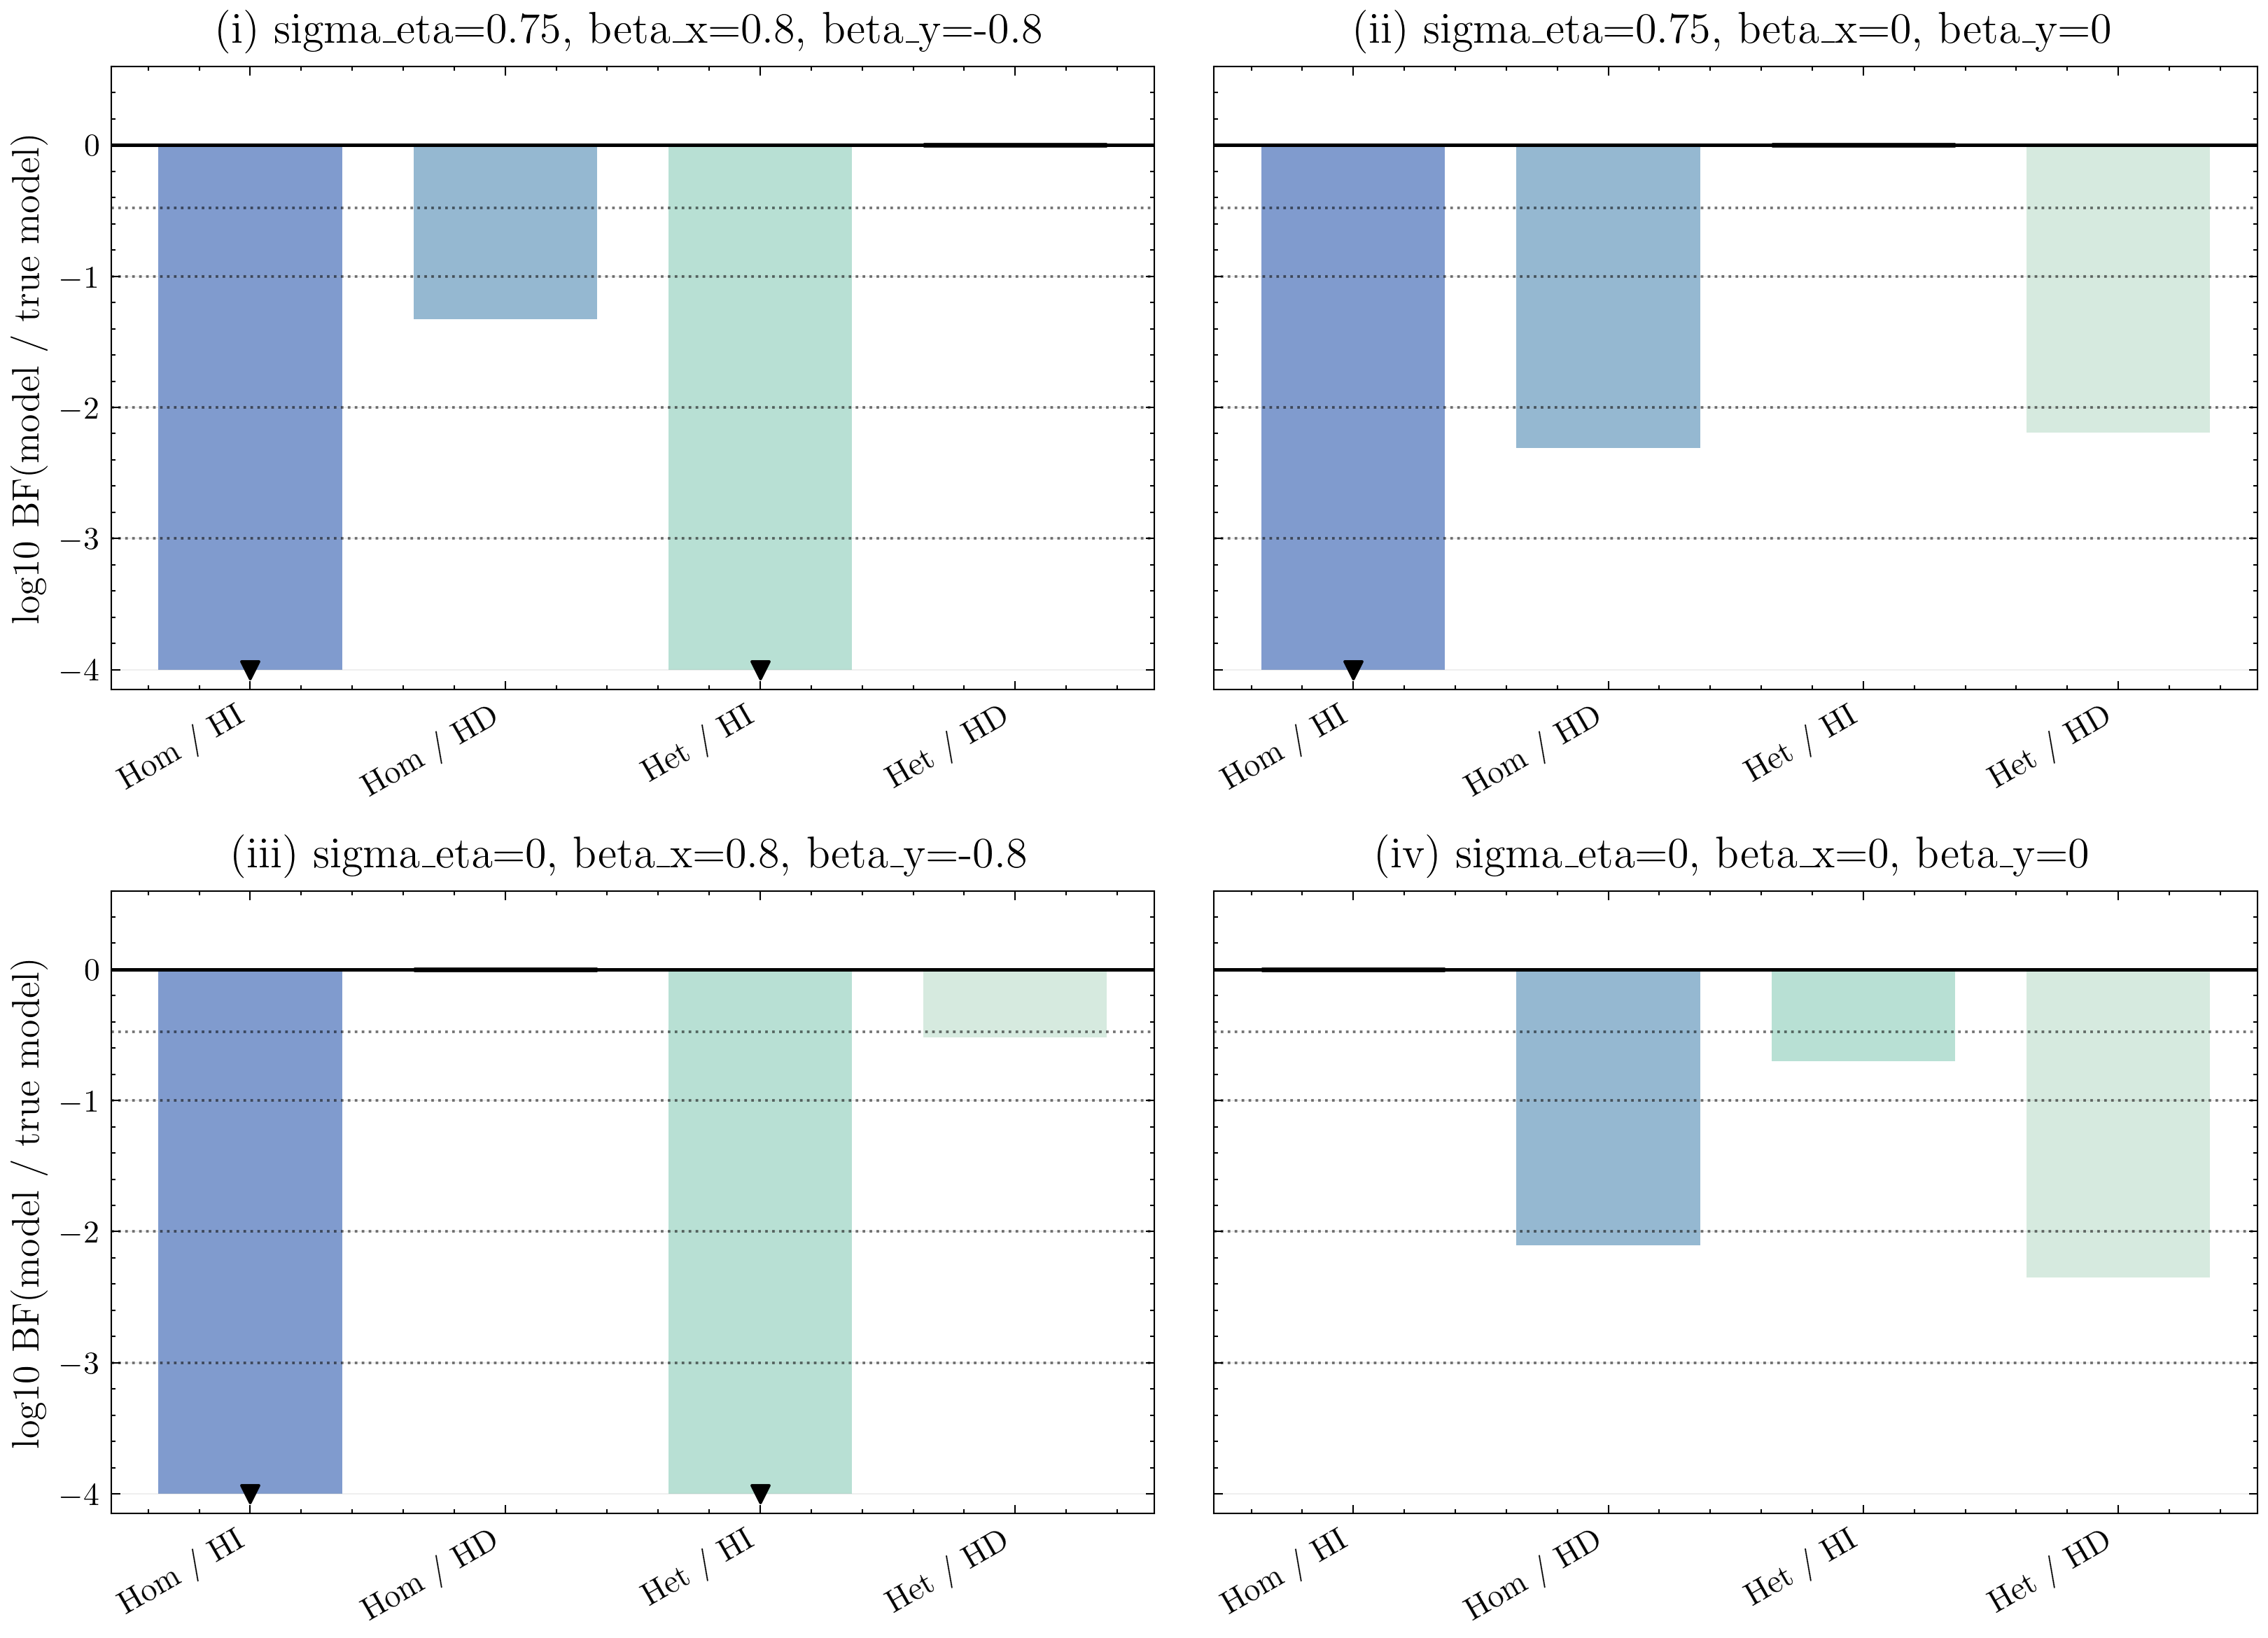

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_3/figures/part_3_bf_500/bf_fixed_n500_rep001_model_vs_true.svg')

In [5]:
def plot_fixed_n_bayes_factors(
    summary: pd.DataFrame,
    *,
    replicate: int | None = None,
    clip_log10_bf: float = 4.0,
    figsize=(11.0, 8.0),
    dpi: int = 300,
):
    if replicate is None:
        replicate = int(summary["replicate"].min())

    data = summary[summary["replicate"] == replicate].copy()
    if data.empty:
        raise ValueError(f"No rows found for replicate {replicate}.")

    scenarios = scenario_order(data)
    fig, axes = plt.subplots(2, 2, figsize=figsize, dpi=dpi, sharey=True)
    axes = axes.ravel()

    for ax, scenario_id in zip(axes, scenarios):
        sub = data[data["scenario"] == scenario_id].copy()
        info = sub.iloc[0]
        values = []
        colors = []
        edgecolors = []
        linewidths = []

        for model_name in MODEL_ORDER:
            row = sub[sub["model"] == model_name].iloc[0]
            values.append(float(row["log10_bf_model_vs_true"]))
            colors.append(MODEL_COLORS.get(model_name, "0.4"))
            is_true = model_name == str(info["true_model"])
            edgecolors.append("black" if is_true else "none")
            linewidths.append(1.6 if is_true else 0.0)

        x = np.arange(len(MODEL_ORDER))
        y = np.clip(values, -clip_log10_bf, clip_log10_bf)
        ax.bar(x, y, color=colors, edgecolor=edgecolors, linewidth=linewidths, width=0.72)

        ax.axhline(0.0, color="black", linewidth=1.2)
        for threshold in [-np.log10(3.0), -1.0, -2.0, -3.0]:
            ax.axhline(threshold, color="black", linestyle=":", linewidth=0.9, alpha=0.55)

        clipped = np.asarray(values) < -clip_log10_bf
        if clipped.any():
            ax.scatter(
                x[clipped],
                np.full(clipped.sum(), -clip_log10_bf),
                marker="v",
                color="black",
                s=35,
                zorder=4,
            )

        ax.set_title(scenario_title(info), fontsize=15, pad=8)
        ax.set_xticks(x)
        ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODEL_ORDER], rotation=30, ha="right", fontsize=11)
        ax.tick_params(axis="y", labelsize=11)
        ax.grid(axis="y", alpha=0.2)
        ax.set_ylim(-clip_log10_bf - 0.15, max(0.6, min(clip_log10_bf, max(values) + 0.25)))

    for ax in axes[len(scenarios):]:
        ax.set_visible(False)

    axes[0].set_ylabel("log10 BF(model / true model)", fontsize=13)
    axes[2].set_ylabel("log10 BF(model / true model)", fontsize=13)
    fig.tight_layout()
    return fig, axes


plot_replicate = int(summary_df["replicate"].min())
fig, axes = plot_fixed_n_bayes_factors(summary_df, replicate=plot_replicate)
out_path = FIGURE_ROOT / f"bf_fixed_n{N_CELLS}_rep{plot_replicate:03d}_model_vs_true.svg"
fig.savefig(out_path, bbox_inches="tight", transparent=True)
plt.show()
out_path

,scenario,best_model,second_model,best_logml,second_logml,log10_bf_best_vs_second
0,No3,homogeneous_history_dependent,heterogeneous_history_dependent,-2356.803,-2357.999,0.519
1,No4,homogeneous_history_independent,heterogeneous_history_independent,-2308.180,-2309.790,0.699


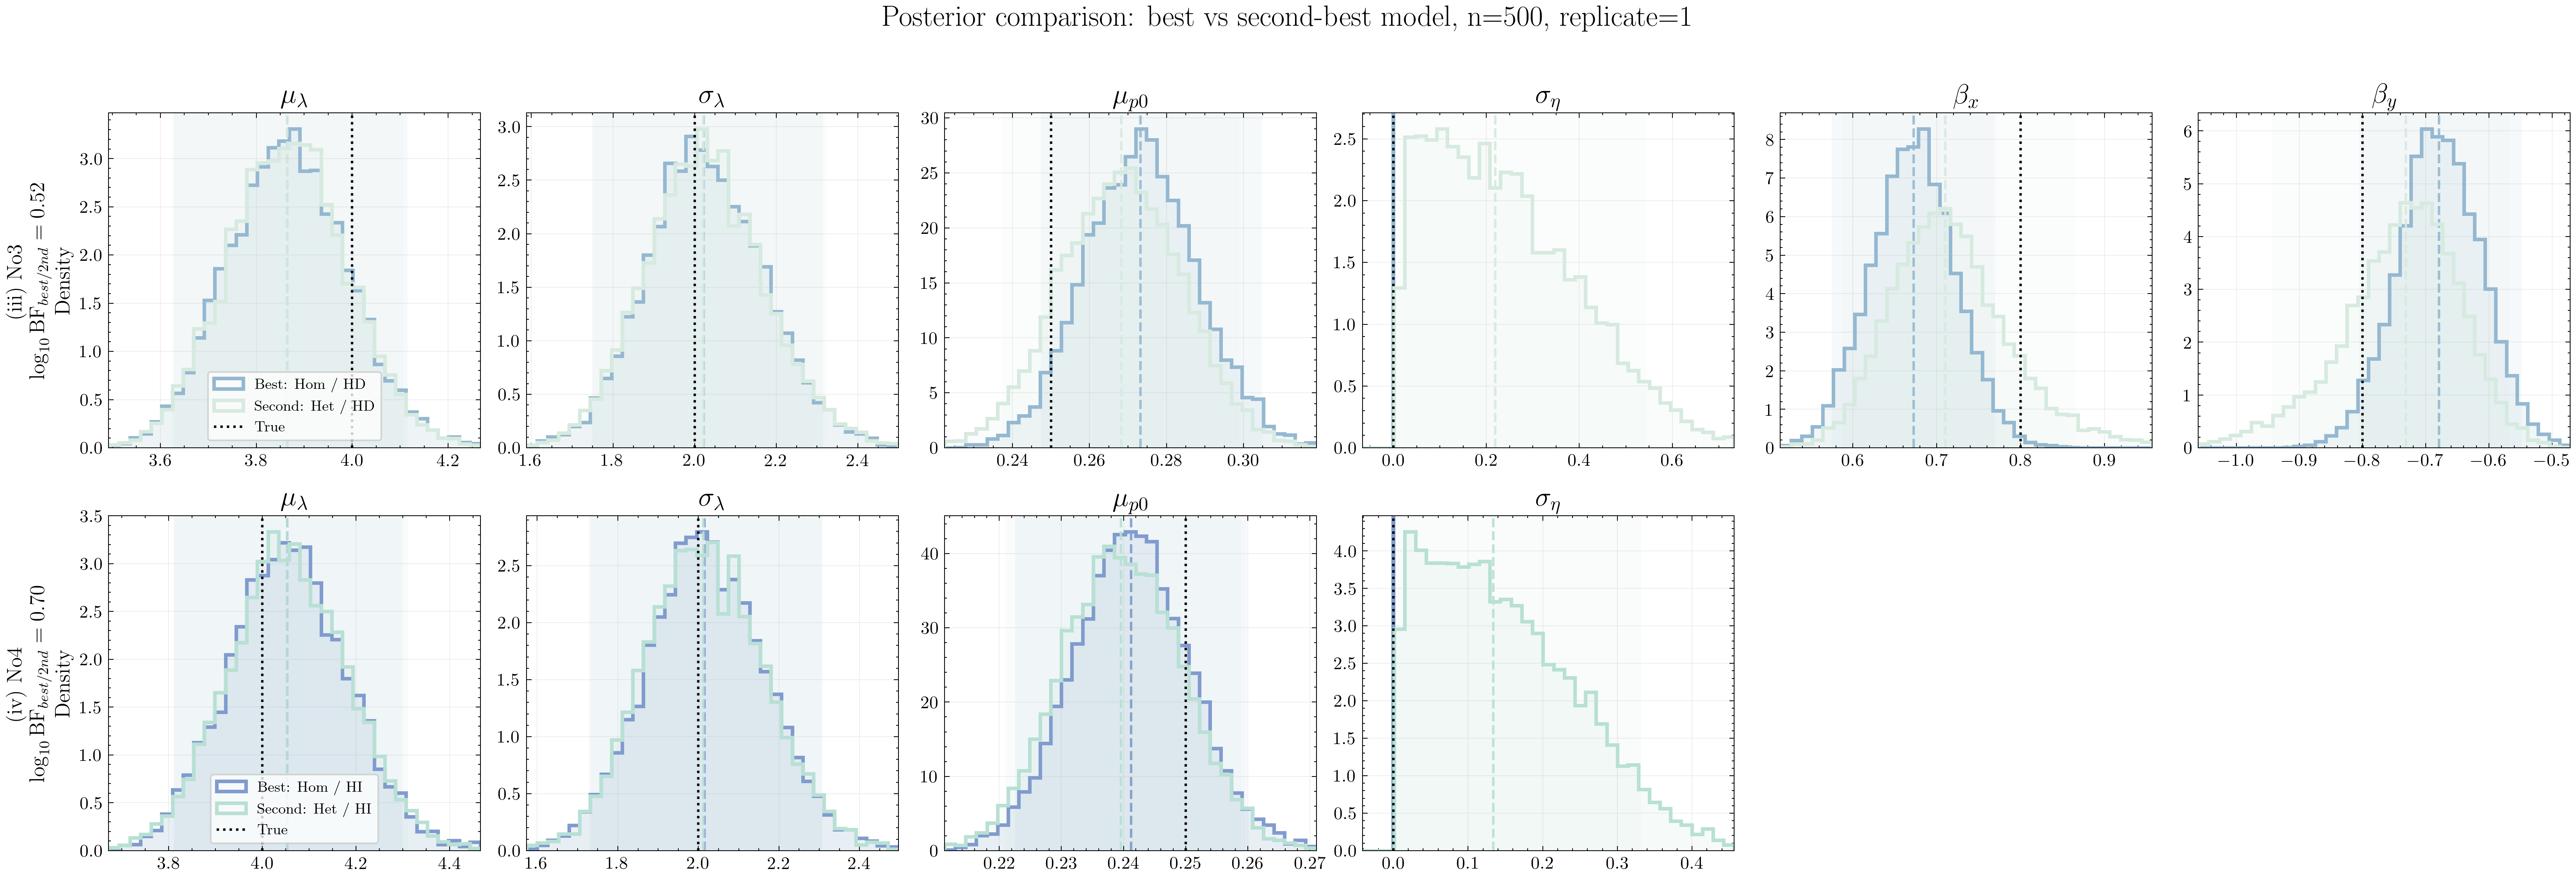

PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_3/figures/part_3_bf_500/posterior_best_vs_second_n500_rep001_iii_iv.svg')

In [6]:
import arviz as az
from matplotlib.lines import Line2D


PARAM_ORDER = [
    "mu_lambda",
    "sigma_lambda",
    "mu_p0",
    "sigma_eta",
    "beta_x",
    "beta_y",
]

PARAM_DISPLAY = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "mu_p0": r"$\mu_{p0}$",
    "sigma_eta": r"$\sigma_\eta$",
    "beta_x": r"$\beta_x$",
    "beta_y": r"$\beta_y$",
}


def posterior_path_for_fit(
    scenario: str,
    replicate: int,
    n_cells: int,
    model_name: str,
    *,
    result_root: Path = RESULT_ROOT,
) -> Path:
    return (
        result_root
        / str(scenario)
        / f"rep_{int(replicate):03d}"
        / f"n_{int(n_cells)}"
        / str(model_name)
        / "posterior.nc"
    )


def true_parameter_path(
    scenario: str,
    replicate: int,
    n_cells: int,
    *,
    result_root: Path = RESULT_ROOT,
) -> Path:
    return (
        result_root
        / str(scenario)
        / f"rep_{int(replicate):03d}"
        / f"n_{int(n_cells)}"
        / "true_parameters.csv"
    )


def flat_posterior_samples(
    idata: az.InferenceData,
    param: str,
    *,
    sample_size: int | None = 8000,
    seed: int = 17,
) -> np.ndarray:
    values = (
        idata.posterior[param]
        .stack(sample=("chain", "draw"))
        .values
        .ravel()
        .astype(float)
    )
    values = values[np.isfinite(values)]

    if sample_size is not None and values.size > sample_size:
        rng = np.random.default_rng(seed)
        values = values[rng.choice(values.size, size=sample_size, replace=False)]

    return values


def is_degenerate(values: np.ndarray, *, tol: float = 1e-10) -> bool:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return True

    return float(np.nanstd(values)) <= tol


def shared_nontrivial_parameters(
    best_idata: az.InferenceData,
    second_idata: az.InferenceData,
    *,
    param_order: list[str] = PARAM_ORDER,
) -> list[str]:
    params = []

    for param in param_order:
        if param not in best_idata.posterior or param not in second_idata.posterior:
            continue

        best_values = flat_posterior_samples(best_idata, param, sample_size=None)
        second_values = flat_posterior_samples(second_idata, param, sample_size=None)

        best_fixed = is_degenerate(best_values)
        second_fixed = is_degenerate(second_values)

        if best_fixed and second_fixed:
            best_value = float(np.nanmedian(best_values)) if best_values.size else np.nan
            second_value = float(np.nanmedian(second_values)) if second_values.size else np.nan

            if np.isclose(best_value, second_value, atol=1e-10):
                continue

        params.append(param)

    return params


def axis_limits_from_samples(sample_sets: list[np.ndarray], true_value=None) -> tuple[float, float]:
    values = []

    for samples in sample_sets:
        samples = np.asarray(samples, dtype=float)
        samples = samples[np.isfinite(samples)]

        if samples.size:
            values.append(samples)

    if true_value is not None and np.isfinite(true_value):
        values.append(np.asarray([true_value], dtype=float))

    if not values:
        return -1.0, 1.0

    all_values = np.concatenate(values)

    if all_values.size >= 5:
        lo, hi = np.nanpercentile(all_values, [0.5, 99.5])
    else:
        lo, hi = float(np.nanmin(all_values)), float(np.nanmax(all_values))

    if np.isclose(lo, hi):
        pad = max(0.1 * abs(lo), 0.5)
    else:
        pad = 0.10 * (hi - lo)

    return float(lo - pad), float(hi + pad)


def plot_one_posterior_marginal(
    ax,
    samples: np.ndarray,
    *,
    color: str,
    label: str,
    bins,
    hdi_prob: float = 0.95,
):
    samples = np.asarray(samples, dtype=float)
    samples = samples[np.isfinite(samples)]

    if samples.size == 0:
        return

    if is_degenerate(samples):
        value = float(np.nanmedian(samples))
        ax.axvline(value, color=color, linewidth=2.5, linestyle="-", label=label)
        return

    hdi_low, hdi_high = np.asarray(az.hdi(samples, hdi_prob=hdi_prob), dtype=float)
    median = float(np.nanmedian(samples))

    ax.axvspan(hdi_low, hdi_high, color=color, alpha=0.08, linewidth=0)
    ax.hist(samples, bins=bins, density=True, histtype="stepfilled", color=color, alpha=0.12)
    ax.hist(samples, bins=bins, density=True, histtype="step", color=color, linewidth=2.2, label=label)
    ax.axvline(median, color=color, linewidth=1.5, linestyle="--", alpha=0.9)


def plot_best_second_posterior_comparison(
    summary: pd.DataFrame,
    *,
    scenarios: tuple[str, ...] = ("No3", "No4"),
    replicate: int | None = None,
    n_cells: int = N_CELLS,
    result_root: Path = RESULT_ROOT,
    figure_root: Path = FIGURE_ROOT,
    sample_size: int = 8000,
    bins: int = 35,
    dpi: int = 300,
):
    if replicate is None:
        replicate = int(summary["replicate"].min())

    selections = []
    idata_cache = {}
    true_cache = {}
    params_by_scenario = {}

    for scenario in scenarios:
        sub = (
            summary[
                (summary["scenario"].astype(str) == str(scenario))
                & (summary["replicate"].astype(int) == int(replicate))
                & (summary["n_cells"].astype(int) == int(n_cells))
            ]
            .sort_values("logml", ascending=False)
            .reset_index(drop=True)
        )

        if len(sub) < 2:
            raise ValueError(f"Need at least two fitted models for {scenario}, replicate {replicate}.")

        best = sub.iloc[0]
        second = sub.iloc[1]

        best_model = str(best["model"])
        second_model = str(second["model"])

        best_path = posterior_path_for_fit(scenario, replicate, n_cells, best_model, result_root=result_root)
        second_path = posterior_path_for_fit(scenario, replicate, n_cells, second_model, result_root=result_root)

        if not best_path.exists():
            raise FileNotFoundError(best_path)
        if not second_path.exists():
            raise FileNotFoundError(second_path)

        best_idata = az.from_netcdf(best_path)
        second_idata = az.from_netcdf(second_path)

        idata_cache[(scenario, best_model)] = best_idata
        idata_cache[(scenario, second_model)] = second_idata

        true_path = true_parameter_path(scenario, replicate, n_cells, result_root=result_root)
        true_cache[scenario] = pd.read_csv(true_path).iloc[0].to_dict() if true_path.exists() else {}

        params = shared_nontrivial_parameters(best_idata, second_idata)
        params_by_scenario[scenario] = params

        selections.append(
            {
                "scenario": scenario,
                "scenario_label": scenario_title(best),
                "best_model": best_model,
                "second_model": second_model,
                "best_logml": float(best["logml"]),
                "second_logml": float(second["logml"]),
                "log10_bf_best_vs_second": float((best["logml"] - second["logml"]) / np.log(10.0)),
                "best_path": best_path,
                "second_path": second_path,
            }
        )

    plot_params = [
        param
        for param in PARAM_ORDER
        if any(param in params_by_scenario[scenario] for scenario in scenarios)
    ]

    if not plot_params:
        raise ValueError("No nontrivial shared posterior parameters found to plot.")

    fig, axes = plt.subplots(
        len(scenarios),
        len(plot_params),
        figsize=(3.7 * len(plot_params), 3.7 * len(scenarios)),
        dpi=dpi,
        squeeze=False,
    )

    for row_idx, selection in enumerate(selections):
        scenario = selection["scenario"]
        best_model = selection["best_model"]
        second_model = selection["second_model"]
        best_idata = idata_cache[(scenario, best_model)]
        second_idata = idata_cache[(scenario, second_model)]

        best_color = MODEL_COLORS.get(best_model, "#2F80ED")
        second_color = MODEL_COLORS.get(second_model, "#D96C06")

        row_first_active_ax = None

        for col_idx, param in enumerate(plot_params):
            ax = axes[row_idx, col_idx]

            if param not in params_by_scenario[scenario]:
                ax.axis("off")
                continue

            if row_first_active_ax is None:
                row_first_active_ax = ax

            best_samples = flat_posterior_samples(
                best_idata,
                param,
                sample_size=sample_size,
                seed=101 + row_idx + col_idx,
            )
            second_samples = flat_posterior_samples(
                second_idata,
                param,
                sample_size=sample_size,
                seed=301 + row_idx + col_idx,
            )

            true_value = true_cache.get(scenario, {}).get(param, np.nan)
            xmin, xmax = axis_limits_from_samples([best_samples, second_samples], true_value=true_value)
            bin_edges = np.linspace(xmin, xmax, bins + 1)

            plot_one_posterior_marginal(
                ax,
                best_samples,
                color=best_color,
                label=f"Best: {MODEL_DISPLAY.get(best_model, best_model)}",
                bins=bin_edges,
            )
            plot_one_posterior_marginal(
                ax,
                second_samples,
                color=second_color,
                label=f"Second: {MODEL_DISPLAY.get(second_model, second_model)}",
                bins=bin_edges,
            )

            if np.isfinite(true_value):
                ax.axvline(true_value, color="black", linewidth=1.5, linestyle=":", label="True")

            ax.set_xlim(xmin, xmax)
            ax.set_title(PARAM_DISPLAY.get(param, param), fontsize=17)
            ax.tick_params(axis="both", labelsize=11)
            ax.grid(alpha=0.2)

            if col_idx == 0:
                roman = SCENARIO_ROMAN.get(str(scenario), str(scenario))
                ax.set_ylabel(
                    f"({roman}) {scenario}\n"
                    rf"$\log_{{10}}\mathrm{{BF}}_{{best/2nd}}={selection['log10_bf_best_vs_second']:.2f}$"
                    "\nDensity",
                    fontsize=13,
                )
            else:
                ax.set_ylabel("")

        if row_first_active_ax is not None:
            handles, labels = row_first_active_ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            row_first_active_ax.legend(
                by_label.values(),
                by_label.keys(),
                frameon=True,
                fontsize=9,
                loc="best",
            )

    fig.suptitle(
        f"Posterior comparison: best vs second-best model, n={n_cells}, replicate={replicate}",
        fontsize=18,
        y=1.02,
    )
    fig.tight_layout()

    figure_root.mkdir(parents=True, exist_ok=True)
    out_path = figure_root / f"posterior_best_vs_second_n{n_cells}_rep{replicate:03d}_iii_iv.svg"
    fig.savefig(out_path, bbox_inches="tight", transparent=True)

    return fig, axes, pd.DataFrame(selections), out_path


try:
    plot_replicate
except NameError:
    plot_replicate = int(summary_df["replicate"].min())

fig, axes, best_second_table, best_second_posterior_path = plot_best_second_posterior_comparison(
    summary_df,
    scenarios=("No3", "No4"),
    replicate=plot_replicate,
)

display(
    best_second_table[
        [
            "scenario",
            "best_model",
            "second_model",
            "best_logml",
            "second_logml",
            "log10_bf_best_vs_second",
        ]
    ].round(3)
)

plt.show()
best_second_posterior_path